請選擇回測年數 (1~5年)：1


[*********************100%***********************]  72 of 72 completed


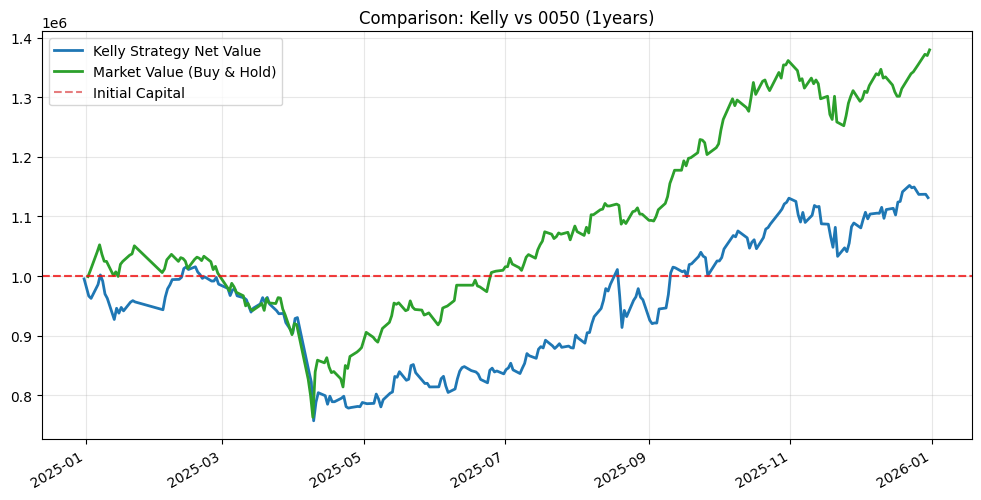

In [2]:
import datetime
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#共有參數設定
capital = 1000000
fee_rate = 0.001425
fee_discount = 0.6
ticker_symbol = "0050.TW"
initial_capital = 1000000
tax_rate = 0.001

while True:
    try:
        years = int(input("請選擇回測年數 (1~5年)："))
        if years in [1, 2, 3, 4, 5]:
            break
        else:
            print("請輸入 1, 2, 3, 4, 5")
    except ValueError:
        print("請輸入數字！")
#日期
start_year = 2026 - years
backtest_start_str = f"{start_year}-01-01"
backtest_end_str = "2026-01-01"
start_date = f"{start_year}-01-01"
end_date = "2026-01-01"

with open("2021.01_0050list.txt","r") as f:
    initial_list=f.read().replace("tw","TW").replace('"', " ").replace(","," ").split()
change_list={
    "2021-03-22":{"add":["1590.TW","8046.TW"],"remove":["2883.TW","2890.TW"]},
    "2021-06-21":{"add":["2409.TW","2603.TW","2609.TW","2615.TW"],"remove":["2105.TW","2474.TW","2633.TW","6669.TW"]},
    "2021-09-20":{"add":["8454.TW"],"remove":["1102.TW"]},
    "2021-12-20":{"add":["3037.TW"],"remove":["1402.TW"]},
    "2022-03-21":{"add":["2883.TW"],"remove":["4938.TW"]},
    "2022-06-20":{"add":["6770.TW"],"remove":["8454.TW"]},
    "2022-09-19":{"add":["2890.TW"],"remove":["6770.TW"]},
    "2022-12-19":{"add":["1402.TW"],"remove":["2409.TW"]},
    "2023-03-20":{"add":["1605.TW"],"remove":["8046.TW"]},
    "2023-06-19":{"add":["4938.TW"],"remove":["6415.TW"]},
    "2023-09-18":{"add":["2301.TW","2345.TW","3231.TW","6669.TW"],"remove":["1402.TW","1605.TW","2609.TW","2615.TW"]},
    "2024-03-18":{"add":["3661.TW"],"remove":["9910.TW"]},
    "2024-06-24":{"add":["3017.TW"],"remove":["2801.TW"]},
    "2024-09-23":{"add":["6446.TW"],"remove":["2408.TW"]},
    "2024-12-23":{"add":["2609.TW"],"remove":["1590.TW"]},
    "2025-03-24":{"add":["2615.TW"],"remove":["1326.TW"]},
    "2025-06-23":{"add":["2383.TW"],"remove":["3037.TW"]},
    "2025-09-22":{"add":["2059.TW","6919.TW"],"remove":["1101.TW","6446.TW"]},
    "2025-12-22":{"add":["2408.TW","3665.TW","3653.TW","2360.TW"],"remove":["2609.TW","4938.TW","5871.TW","5876.TW"]},
    }
all_ticket=set(initial_list)
for date in change_list:
    all_ticket.update(change_list[date]["add"])
    all_ticket.update(change_list[date]["remove"])
all_list=list(all_ticket)
# 資料下載
backtest_end=datetime.date(2025,12,31)
backtest_start=backtest_end-datetime.timedelta(days=years*365)
data_fetch_start=backtest_start-datetime.timedelta(days=120)

raw_data=yf.download(all_list, start=data_fetch_start, end=backtest_end, auto_adjust=True)
df=raw_data["Close"]
df=df.ffill()
# 凱利公式
def Kelly_value(price):
    returns=price.pct_change().dropna()
    wins=returns[returns>0]
    losses=returns[returns<0]
    win_rate=len(wins)/len(returns)
    win_avg=wins.mean()
    loss_avg=abs(losses.mean())
    reward_to_risk=win_avg/loss_avg

    kelly=(win_rate*(reward_to_risk+1)-1)/reward_to_risk
    return max(0,kelly) #看計算出來的值有沒有比0大，沒有比0大就不買所以顯示0
# 回測
lookback=30
exchange=10
fee_rate=0.001425
fee_discount=0.6
tax_rate=0.003
total_cash=capital
current_stock=initial_list.copy()
current_portfolio={}
net_value_history=pd.Series(dtype=float)
trade_days=df.index[df.index>=np.datetime64(backtest_start)]

for i in range(0,len(trade_days),exchange):
    today=trade_days[i]

    for change_date_str, info in change_list.items():
        change_date=datetime.datetime.strptime(change_date_str,"%Y-%m-%d").date()
        if change_date<=today.date():
            current_stock=list(set(current_stock).union(info["add"]).difference(info["remove"]))

    if current_portfolio:
        for stock, shares in current_portfolio.items():
            sell_price=df.loc[today, stock]
            gross_sell=shares*sell_price
            net_sell=gross_sell*(1-fee_rate-tax_rate)
            total_cash+=net_sell
        current_portfolio={}

    lookback_data = df.loc[:today].tail(lookback)

    kelly_scores={stock:Kelly_value(lookback_data[stock])
                  for stock in current_stock if stock in lookback_data.columns}
    top10=sorted(kelly_scores.items(), key=lambda x:x[1], reverse=True)[:10]
    top10_final=[(stock, score) for stock, score in top10 if score>0]
# 買入新持股
    if top10_final:
        total_score=sum(s[1] for s in top10_final)
        for stock, score in top10_final:
            weight=score/total_score
            buy_price=df.loc[today, stock]

            allocated_cash=total_cash*weight

            shares=allocated_cash/(buy_price*(1+fee_rate*fee_discount))
            current_portfolio[stock]=shares
        total_cash=0

    period_end_idx = min(i + exchange, len(trade_days))
    for j in range(i, period_end_idx):
        day=trade_days[j]
        if current_portfolio:
            daily_market_value=sum(shares*df.loc[day, s] for s, shares in current_portfolio.items())
            net_value=daily_market_value*(1-fee_rate*fee_discount-tax_rate)
        else:
            net_value=total_cash
        net_value_history[day]=net_value

stock = yf.Ticker(ticker_symbol)
df = stock.history(start=start_date, end=end_date)
if df.empty:
    print("找不到資料")
else:
    # 取得價格序列
    prices = df['Close']
    start_price = prices.iloc[0]

    #計算買進後的持股數
    buy_fee_factor = 1 + (fee_rate * fee_discount)
    shares_owned = initial_capital / (start_price * buy_fee_factor)
    market_value_series = prices * shares_owned

    #夏普值計算
    daily_returns = market_value_series.pct_change().dropna()
    risk_free_rate = 0.02  # 假設年化無風險利率 2%
    trading_days_per_year = 252
    annual_return = daily_returns.mean() * trading_days_per_year
    annual_volatility = daily_returns.std() * np.sqrt(trading_days_per_year)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

    #結算
    final_market_value = market_value_series.iloc[-1]
    exit_costs = final_market_value * (fee_rate * fee_discount + tax_rate)
    final_net_value = final_market_value - exit_costs
    total_net_profit = final_net_value - initial_capital
    net_roi = (total_net_profit / initial_capital) * 100

#繪圖與比較
plt.figure(figsize=(12, 6))
# 凱利組
plt.plot(net_value_history.index, net_value_history.values,color='#1f77b4', linewidth=2, label='Kelly Strategy Net Value')
# 大盤組
plt.plot(market_value_series.index, market_value_series.values, color='#2ca02c', linewidth=2, label='Market Value (Buy & Hold)')
plt.axhline(y=capital, color='#d62728', linestyle='--', alpha=0.6, label='Initial Capital')
plt.axhline(y=capital, color='red', linestyle='--', alpha=0.5)
plt.title(f'Comparison: Kelly vs 0050 ({years}years)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gcf().autofmt_xdate()
plt.show()